# Preprocessing and Splitting

This notebook prepares the course material and question-answer dataset for the retrieval and generation stages of the project. It loads the previously created text chunks, normalizes and cleans their content, and creates separate text representations for dense and lexical retrieval methods.

The questions and reference answers are processed using the same normalization procedure. Invalid or incomplete examples are removed before the dataset is divided into training, validation, and test sets using an approximately 70:15:15 ratio. Stratified splitting is applied to preserve the original topic distribution across the three subsets.

The notebook also performs a basic dataset analysis, including dataset structure, missing and empty values, split sizes, topic distribution, class imbalance, and overlap between the subsets. Finally, the processed chunks and all three question-answer subsets are saved as JSONL files for use in the TF-IDF, BM25, dense retrieval, and answer generation experiments.

In [1]:
import json
import re
import unicodedata
from pathlib import Path
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

## Loading the chunks

In [2]:
PROJECT_ROOT = Path.cwd()

CHUNKS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "chunks.jsonl"
)


In [3]:
def load_jsonl(path: Path) -> list[dict]:
    records = []

    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            line = line.strip()

            if not line:
                continue

            try:
                record = json.loads(line)
                records.append(record)

            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Neispravan JSON u redu {line_number}."
                ) from error

    return records

In [4]:
chunks = load_jsonl(CHUNKS_PATH)
print(f"Učitano je {len(chunks)} chunkova.")

Učitano je 356 chunkova.


## Preprocessing


The preprocessing stage cleans and normalizes the extracted text before it is used by the retrieval models. Unicode characters, quotation marks, dashes, line breaks, invisible characters, and invalid replacement symbols are normalized or removed. Words split across lines in the original PDF are joined, and multiple whitespace characters are reduced to a single space.

Two versions of each text are created:

- `processed_text` preserves the natural form of the text and is used for dense retrieval and answer generation.
- `lexical_text` is additionally converted to lowercase and stripped of punctuation, making it suitable for TF-IDF and BM25 retrieval.

The original text is preserved in the `text` attribute, allowing the preprocessing results to be compared with the source content.

In [5]:
def preprocess_text(text: str, lexical: bool = False) -> str:
    if not isinstance(text, str):
        return ""

    # Normalizacija Unicode znakova
    text = unicodedata.normalize("NFKC", text)

    # Ako su \n ostali kao bukvalni karakteri "\\" + "n"
    text = text.replace("\\r\\n", "\n")
    text = text.replace("\\n", "\n")
    text = text.replace("\\r", "\n")

    # Standardni prelomi redova
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    # Uklanjanje dekorativnih simbola
    text = re.sub(r"[▶►▪■●◆◇◦•]", " ", text)

    # Uklanjanje nevidljivih znakova
    text = re.sub(
        r"[\u200b\u200c\u200d\u2060\ufeff]",
        "",
        text
    )

    # ---------------------------------------------------
    # SPAJANJE RECI PRELOMLJENIH NA KRAJU REDA
    #
    # informacio-
    # ni  -> informacioni
    # ---------------------------------------------------
    text = re.sub(
        r"(?<=\w)\s*-\s*\n\s*(?=\w)",
        "",
        text
    )

    # Znak zamene
    text = text.replace("�", "")

    # Normalizacija crtica
    text = re.sub(r"[‐-‒–—]", "-", text)

    # Normalizacija navodnika
    text = (
        text
        .replace("“", '"')
        .replace("”", '"')
        .replace("„", '"')
        .replace("’", "'")
        .replace("‘", "'")
    )

    # Preostale prelome redova pretvori u razmake
    text = re.sub(r"\s*\n+\s*", " ", text)

    # Spajanje visestrukih razmaka
    text = re.sub(r"[ \t]+", " ", text)

    if lexical:
        text = text.lower()

        # Interpunkciju pretvori u razmake
        text = re.sub(
            r"[^\w\s\-]",
            " ",
            text,
            flags=re.UNICODE
        )

        text = re.sub(r"\s+", " ", text)

    return text.strip()

In [6]:
processed_chunks = []

for chunk in chunks:
    processed_chunk = chunk.copy()

    # Prirodno ociscen tekst za dense 
    processed_chunk["processed_text"] = preprocess_text(
        chunk.get("text", ""),
        lexical=False
    )

    # Normalizovaniji tekst za TF-IDF / BM25
    processed_chunk["lexical_text"] = preprocess_text(
        chunk.get("text", ""),
        lexical=True
    )

    processed_chunks.append(processed_chunk)

In [7]:
print(f"Broj originalnih chunkova: {len(chunks)}")
print(f"Broj obrađenih chunkova: {len(processed_chunks)}")

Broj originalnih chunkova: 356
Broj obrađenih chunkova: 356


In [8]:
example_chunk = processed_chunks[0]

print("PRE SREĐIVANJA:\n")
print(example_chunk["text"][:700])

print("\nDENSE VERZIJA:\n")
print(example_chunk["processed_text"][:700])

print("\nLEXICAL VERZIJA (TF-IDF / BM25):\n")
print(example_chunk["lexical_text"][:700])

PRE SREĐIVANJA:

Pregled
1.1 Upravljanje kvalitetom softvera . . 4
-Koji procesi su važni za kvalitet softvera? -Koji su standardi kvaliteta softvera najbitnĳi i šta oni definišu?
1.2 Standardi . . . . . 4
1.3 Atributi kvaliteta softvera . . . . . . 5
-Kojim se atributima opisuje kvalitet softvera? -Koji atributi kvaliteta softvera su važni za bankarske aplikacĳe, koji za autonomnu vožnju, koji za kalkulator, koji za onlajn prodaju karata, a koji za sisteme za razmenu poruka?
Tokom poslednjih godina, IT industrĳa se brzo razvija i predstavlja jednu od najdinamičnĳih industrĳa u svetu. Softver se razvĳa za veoma raznovrsne uređaje i svrhe. Ove namene obuhvataju oblasti poput interneta stvari, virtuelne i proš

DENSE VERZIJA:

Pregled 1.1 Upravljanje kvalitetom softvera . . 4 -Koji procesi su važni za kvalitet softvera? -Koji su standardi kvaliteta softvera najbitniji i šta oni definišu? 1.2 Standardi . . . . . 4 1.3 Atributi kvaliteta softvera . . . . . . 5 -Kojim se atributima opisuje 

In [9]:
empty_chunks = [
    chunk["chunk_id"]
    for chunk in processed_chunks
    if not chunk["processed_text"] or not chunk["lexical_text"]
]

print(f"Broj praznih chunkova: {len(empty_chunks)}")

if empty_chunks:
    print("Prazni chunkovi:", empty_chunks)

Broj praznih chunkova: 0


## Loading the questions

In [10]:
QA_PATH = (
    PROJECT_ROOT
    / "data"
    / "questions"
    / "questions_answers.json"
)

with QA_PATH.open("r", encoding="utf-8") as file:
    qa_examples = json.load(file)

print(f"Učitano pitanja: {len(qa_examples)}")

Učitano pitanja: 143


In [11]:
processed_qa = []

for example in qa_examples:
    processed_example = example.copy()

    # Dense verzija pitanja
    processed_example["processed_question"] = preprocess_text(
        example.get("question", ""),
        lexical=False
    )

    # Leksikalna verzija pitanja za TF-IDF / BM25
    processed_example["lexical_question"] = preprocess_text(
        example.get("question", ""),
        lexical=True
    )

    # Prirodno ociscena dense verzija odgovora
    processed_example["processed_answer"] = preprocess_text(
        example.get("answer", ""),
        lexical=False
    )

    # Leksikalna verzija odgovora za TF-IDF / BM25
    processed_example["lexical_answer"] = preprocess_text(
        example.get("answer", ""),
        lexical=True
    )

    source = example.get("source", {})
    source_pages = source.get("page", [])

    if isinstance(source_pages, int):
        source_pages = [source_pages]

    processed_example["source_pages"] = source_pages

    processed_qa.append(processed_example)

In [12]:
valid_qa = []

for example in processed_qa:
    question = example.get("processed_question", "")
    lexical_question = example.get("lexical_question", "")
    answer = example.get("processed_answer", "")
    lexical_answer = example.get("lexical_answer", "")
    source_pages = example.get("source_pages", [])

    if question and lexical_question and answer and lexical_answer and source_pages:
        valid_qa.append(example)

print(f"Broj pitanja spremnih za podelu: {len(valid_qa)}")

Broj pitanja spremnih za podelu: 143


## Data Splitting

In [13]:
train_data, temporary_data = train_test_split(
    valid_qa,
    test_size=0.30,
    random_state=42,
    shuffle=True,
    stratify=[
        example["topic"]
        for example in valid_qa
    ]
)

In [14]:
validation_data, test_data = train_test_split(
    temporary_data,
    test_size=0.50,
    random_state=42,
    shuffle=True,
    stratify=[
        example["topic"]
        for example in temporary_data
    ]
)

In [15]:
total = len(valid_qa)

print(
    f"Training: {len(train_data)} "
    f"({len(train_data) / total:.2%})"
)

print(
    f"Validation: {len(validation_data)} "
    f"({len(validation_data) / total:.2%})"
)

print(
    f"Test: {len(test_data)} "
    f"({len(test_data) / total:.2%})"
)

Training: 100 (69.93%)
Validation: 21 (14.69%)
Test: 22 (15.38%)


In [16]:
train_ids = {
    example["id"]
    for example in train_data
}

validation_ids = {
    example["id"]
    for example in validation_data
}

test_ids = {
    example["id"]
    for example in test_data
}

assert train_ids.isdisjoint(validation_ids)
assert train_ids.isdisjoint(test_ids)
assert validation_ids.isdisjoint(test_ids)

assert len(
    train_ids | validation_ids | test_ids
) == len(valid_qa)

print("Nema preklapanja između skupova.")

Nema preklapanja između skupova.


## **Data Analysis**


In [17]:
train_df = pd.DataFrame(train_data)
train_df["split"] = "Training"

validation_df = pd.DataFrame(validation_data)
validation_df["split"] = "Validation"

test_df = pd.DataFrame(test_data)
test_df["split"] = "Test"

qa_df = pd.concat(
    [
        train_df,
        validation_df,
        test_df
    ],
    ignore_index=True
)

print(f"Ukupan broj primera: {len(qa_df)}")
print(f"Broj atributa: {len(qa_df.columns)}")
print("\nAtributi skupa:")

for column in qa_df.columns:
    print(f"- {column}")

Ukupan broj primera: 143
Broj atributa: 12

Atributi skupa:
- id
- question
- answer
- topic
- subtopic
- source
- processed_question
- lexical_question
- processed_answer
- lexical_answer
- source_pages
- split


In [18]:
important_columns = [
    "id",
    "topic",
    "subtopic",
    "processed_question",
    "processed_answer",
    "source_pages"
]

missing_values = (
    qa_df[important_columns]
    .isna()
    .sum()
    .rename("Broj nedostajućih vrednosti")
)

print(missing_values)

id                    0
topic                 0
subtopic              0
processed_question    0
processed_answer      0
source_pages          0
Name: Broj nedostajućih vrednosti, dtype: int64


In [19]:
empty_questions = sum(
    not question.strip()
    for question in qa_df["processed_question"].fillna("")
)

empty_answers = sum(
    not answer.strip()
    for answer in qa_df["processed_answer"].fillna("")
)

empty_source_pages = sum(
    not isinstance(pages, list) or len(pages) == 0
    for pages in qa_df["source_pages"]
)

print(f"Broj praznih pitanja: {empty_questions}")
print(f"Broj praznih odgovora: {empty_answers}")
print(f"Broj pitanja bez izvornih stranica: {empty_source_pages}")

Broj praznih pitanja: 0
Broj praznih odgovora: 0
Broj pitanja bez izvornih stranica: 0


In [20]:
topic_distribution = (
    qa_df
    .groupby([
        "topic",
        "split"
    ])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "Training",
            "Validation",
            "Test"
        ]
    )
)

topic_distribution

split,Training,Validation,Test
topic,,,
Dinamička verifikacija softvera,78,17,17
Ispravnost i neispravnost softvera,22,4,5


In [21]:
topic_table = (
    topic_distribution
    .reset_index()
    .rename(columns={
        "topic": "Tema",
        "Training": "Trening",
        "Validation": "Validacija",
        "Test": "Test"
    })
)

topic_table["Ukupno"] = (
    topic_table["Trening"]
    + topic_table["Validacija"]
    + topic_table["Test"]
)

display(
    topic_table.style
    .hide(axis="index")
    .set_caption("Raspodela pitanja po temama")
    .set_properties(**{
        "text-align": "center"
    })
    .set_properties(
        subset=["Tema"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("margin-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#e8eef7")
            ]
        }
    ])
)

Tema,Trening,Validacija,Test,Ukupno
Dinamička verifikacija softvera,78,17,17,112
Ispravnost i neispravnost softvera,22,4,5,31


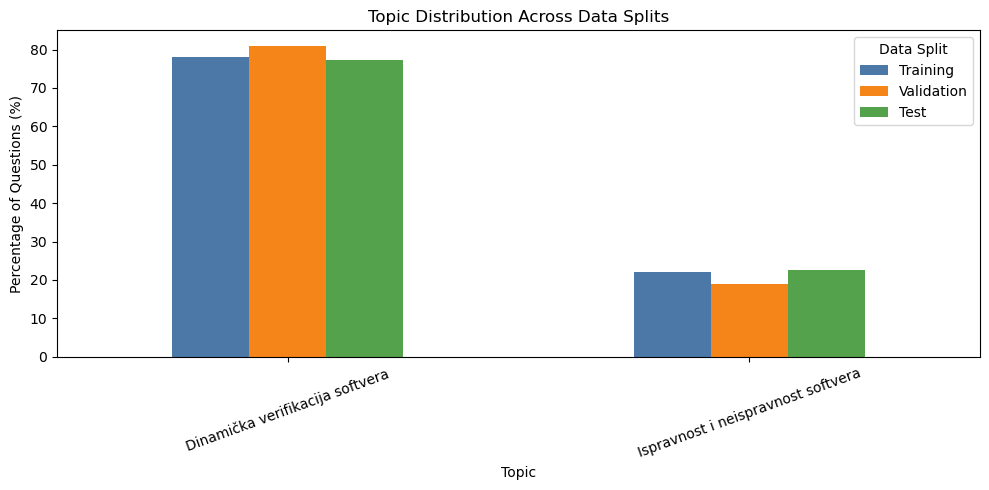

In [22]:
topic_percentages = (
    topic_distribution
    .div(
        topic_distribution.sum(axis=0),
        axis=1
    )
    * 100
)

topic_percentages = topic_percentages.reindex(
    columns=[
        "Training",
        "Validation",
        "Test"
    ]
)

ax = topic_percentages.plot(
    kind="bar",
    figsize=(10, 5),
    color=[
        "#4C78A8",
        "#F58518",
        "#54A24B"
    ]
)

ax.set_title("Topic Distribution Across Data Splits")
ax.set_xlabel("Topic")
ax.set_ylabel("Percentage of Questions (%)")
ax.tick_params(
    axis="x",
    rotation=20
)

ax.legend(
    title="Data Split"
)

plt.tight_layout()
plt.show()

### **Analysis Summary**
The dataset contains 356 text chunks and 143 question-answer pairs. After preprocessing, no empty chunks were found, and all 143 question-answer pairs were retained for further processing.

The question-answer dataset contains 12 attributes, including the original and preprocessed versions of questions and answers, topic and subtopic labels, source information, source pages, and the assigned data split.

No missing values were detected in the important attributes. There are no empty questions, empty answers, or examples without corresponding source pages.

The dataset was divided into training, validation, and test sets using an approximately 70:15:15 ratio:

- Training set: 100 examples (69.93%)
- Validation set: 21 examples (14.69%)
- Test set: 22 examples (15.38%)

The three subsets do not overlap, and every valid question-answer pair belongs to exactly one subset.

The dataset is imbalanced with respect to the main topic. Approximately 78% of the examples belong to *Dynamic Software Verification*, while approximately 22% belong to *Software Correctness and Incorrectness*.

Stratified splitting preserved approximately the same topic proportions in the training, validation, and test sets. Therefore, all three subsets remain imbalanced, but their topic distributions are mutually consistent.

## Chunk Analysis

The processed text chunks are analyzed before they are used by the retrieval models. The analysis examines their structure, length distribution, page coverage, duplicate content, and potential empty or unusually short chunks. This helps verify that the chunking and preprocessing stages produced a suitable retrieval corpus.

In [ ]:
# import json
# from pathlib import Path
# import pandas as pd
# import matplotlib.pyplot as plt

# PROJECT_ROOT = Path.cwd()

# PROCESSED_CHUNKS_PATH = (
#     PROJECT_ROOT
#     / "data"
#     / "processed"
#     / "chunks_preprocessed.jsonl"
# )

# def load_jsonl(path: Path) -> list[dict]:
#     with path.open("r", encoding="utf-8") as file:
#         return [
#             json.loads(line)
#             for line in file
#             if line.strip()
#         ]

# processed_chunks = load_jsonl(PROCESSED_CHUNKS_PATH)

# print(f"Loaded {len(processed_chunks)} processed chunks.")

# chunks_df = pd.DataFrame(processed_chunks)

Loaded 356 processed chunks.


In [2]:
chunks_df = pd.DataFrame(processed_chunks)

print(f"Ukupan broj chunkova: {len(chunks_df)}")
print(f"Broj atributa: {len(chunks_df.columns)}")

print("\nAtributi chunkova:")
for column in chunks_df.columns:
    print(f"- {column}")

Ukupan broj chunkova: 356
Broj atributa: 12

Atributi chunkova:
- chunk_id
- text
- token_count
- body_token_count
- pdf_page_start
- pdf_page_end
- printed_page_start
- printed_page_end
- section_ref
- heading
- processed_text
- lexical_text


In [5]:
chunks_df["char_count"] = (
    chunks_df["processed_text"]
    .str.len()
)

chunks_df["word_count"] = (
    chunks_df["processed_text"]
    .str.split()
    .str.len()
)

chunk_length_stats = pd.DataFrame({
    "Karakteri": chunks_df["char_count"].describe(),
    "Reči": chunks_df["word_count"].describe()
})

chunk_length_stats

,Karakteri,Reči
count,356.000000,356.000000
mean,1077.191011,149.483146
std,79.495611,12.756539
min,684.000000,99.000000
25%,1041.000000,142.000000
50%,1088.500000,149.000000
75%,1122.000000,157.000000
max,1332.000000,232.000000


In [6]:
print("Statistika broja reči u čistim chunkovima:\n")

print(
    f"Mininamal broj reči: "
    f"{chunks_df['word_count'].min()}"
)

print(
    f"Prosecna broj reči: "
    f"{chunks_df['word_count'].mean():.2f}"
)

print(
    f"Mediana broja reči: "
    f"{chunks_df['word_count'].median():.2f}"
)

print(
    f"Maximalan broj reči: "
    f"{chunks_df['word_count'].max()}"
)

Statistika broja reči u čistim chunkovima:

Mininamal broj reči: 99
Prosecna broj reči: 149.48
Mediana broja reči: 149.00
Maximalan broj reči: 232


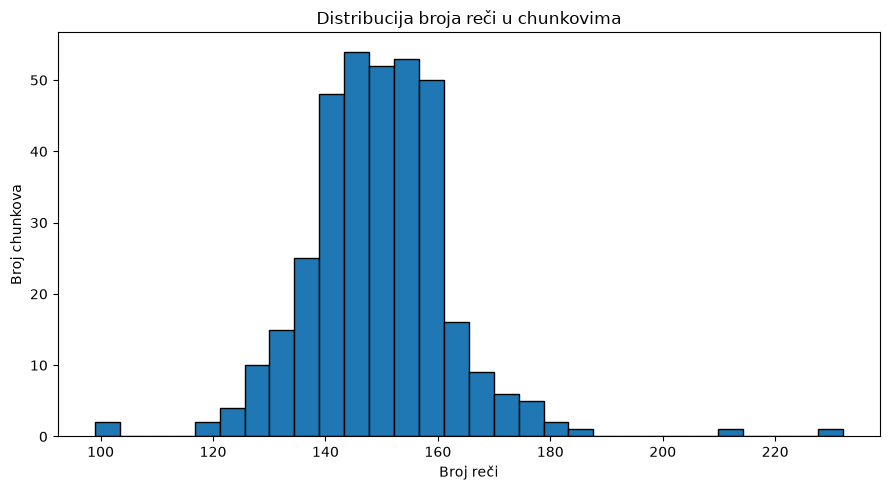

In [7]:
plt.figure(figsize=(9, 5))

plt.hist(
    chunks_df["word_count"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribucija broja reči u chunkovima")
plt.xlabel("Broj reči")
plt.ylabel("Broj chunkova")

plt.tight_layout()
plt.show()

In [9]:
SHORT_CHUNK_THRESHOLD = 50

short_chunks = chunks_df[
    chunks_df["word_count"] < SHORT_CHUNK_THRESHOLD
]

print(
    f"Chunkovi kraći od {SHORT_CHUNK_THRESHOLD} reči: "
    f"{len(short_chunks)}"
)

Chunkovi kraći od 50 reči: 0


In [10]:
short_chunks[
    [
        "chunk_id",
        "pdf_page_start",
        "pdf_page_end",
        "word_count",
        "processed_text"
    ]
].head(10)

,chunk_id,pdf_page_start,pdf_page_end,word_count,processed_text


In [11]:
longest_chunks = (
    chunks_df
    .sort_values(
        "word_count",
        ascending=False
    )
    [
        [
            "chunk_id",
            "pdf_page_start",
            "pdf_page_end",
            "word_count",
            "processed_text"
        ]
    ]
    .head(10)
)

longest_chunks

,chunk_id,pdf_page_start,pdf_page_end,word_count,processed_text
322,chunk_0323,186,188,232,[Profajliranje i dinamičko detektovanje grešak...
321,chunk_0322,186,187,212,[Profajliranje i dinamičko detektovanje grešak...
271,chunk_0272,160,160,184,[Debagovanje] alizu sistemskih logova i izlazn...
262,chunk_0263,154,155,179,[Debagovanje] Primer 5.2.4 (Interaktivno debag...
9,chunk_0010,21,22,179,[Atributi kvaliteta softvera] ata i kapacitet ...
286,chunk_0287,167,168,177,[Štampanje umesto debagera > 5.5 Štampanje ume...
320,chunk_0321,185,186,177,"[Profajleri] alata oprofile, kao i da pruži mo..."
272,chunk_0273,160,161,175,[Debagovanje] odgvarajući sistemski servis za ...
282,chunk_0283,166,166,175,[Debagovanje > 5.4 Otvoreni problemi] ponašanj...
265,chunk_0266,156,157,175,"[Debagovanje] aka 3. Slično, komandom 1 watch ..."


In [12]:
chunks_df["page_span"] = (
    chunks_df["pdf_page_end"]
    - chunks_df["pdf_page_start"]
    + 1
)

page_span_distribution = (
    chunks_df["page_span"]
    .value_counts()
    .sort_index()
)

page_span_distribution

page_span
1    124
2    228
3      2
4      2
Name: count, dtype: int64

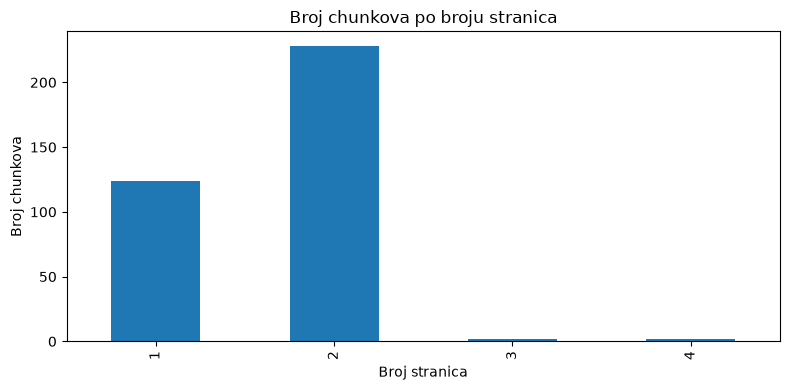

In [13]:
ax = page_span_distribution.plot(
    kind="bar",
    figsize=(8, 4)
)

ax.set_title("Broj chunkova po broju stranica")
ax.set_xlabel("Broj stranica")
ax.set_ylabel("Broj chunkova")

plt.tight_layout()
plt.show()

In [14]:
duplicate_chunks = chunks_df[
    chunks_df.duplicated(
        subset=["processed_text"],
        keep=False
    )
]

print(
    f"Broj chunkova sa dupliranim tekstom: "
    f"{len(duplicate_chunks)}"
)

Broj chunkova sa dupliranim tekstom: 0


In [15]:
print(
    "Broj jedinstvenih tekstova:",
    chunks_df["processed_text"].nunique()
)

print(
    "Ukupan broj chunkova:",
    len(chunks_df)
)

Broj jedinstvenih tekstova: 356
Ukupan broj chunkova: 356


In [17]:
covered_pages = set()

for _, chunk in chunks_df.iterrows():
    covered_pages.update(
        range(
            int(chunk["pdf_page_start"]),
            int(chunk["pdf_page_end"]) + 1
        )
    )

print(
    f"Broj prekrivenih stranica: "
    f"{len(covered_pages)}"
)

print(
    f"Rang prekrivenih stranica: "
    f"{min(covered_pages)} - {max(covered_pages)}"
)

Broj prekrivenih stranica: 188
Rang prekrivenih stranica: 17 - 204


### Chunk Analysis

The retrieval corpus contains 356 text chunks. All chunks remained non-empty after preprocessing, indicating that the normalization procedure did not remove any complete chunk content.

The chunk corpus was additionally analyzed with respect to text length, page coverage, and duplicate content. Word- and character-level length statistics were calculated to identify unusually short or long chunks, while the page-span distribution was examined to determine how much source material each chunk covers.

Duplicate processed texts were also checked to ensure that identical chunks do not unnecessarily bias retrieval results. Finally, the set of source pages covered by the chunks was inspected to verify the coverage of the original course material.

This analysis provides a basic quality check of the corpus before it is indexed by TF-IDF, BM25, and dense retrieval models.


## Saving the Processed Data

The processed chunks and the training, validation, and test subsets are saved as JSONL files so they can be reused by the retrieval and answer generation notebooks.

In [23]:
PROCESSED_CHUNKS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "chunks_preprocessed.jsonl"
)

SPLITS_DIR = (
    PROJECT_ROOT
    / "data"
    / "splits"
)

SPLITS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [24]:
def save_jsonl(records: list[dict], path: Path) -> None:
    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with path.open("w", encoding="utf-8") as file:
        for record in records:
            file.write(
                json.dumps(
                    record,
                    ensure_ascii=False
                )
                + "\n"
            )

In [25]:
save_jsonl(
    processed_chunks,
    PROCESSED_CHUNKS_PATH
)

TRAIN_PATH = SPLITS_DIR / "train.jsonl"
VALIDATION_PATH = SPLITS_DIR / "validation.jsonl"
TEST_PATH = SPLITS_DIR / "test.jsonl"

save_jsonl(
    train_data,
    TRAIN_PATH
)
save_jsonl(
    validation_data,
    VALIDATION_PATH
)
save_jsonl(
    test_data,
    TEST_PATH
)